---
## VWAP-skew / strangle strategy

Four-regime, always-invested short-options book (20 lots = 10 calls + 10 puts):

1. **spot ≥ VWAP + 20 bps** → skew short: PUT far (−3), CALL near (+1) — pyramided 1–2–3–4 lots/side at 30 s gaps (only if the last 30 s window was profitable), trailing stop + profit limit, 20-min max-hold.
2. **spot ≤ VWAP − 20 bps** → mirror: CALL far (+3), PUT near (−1); same pyramid / stops / hold.
3. **else, trailing-15-min range < 15 bps** → tight strangle on the two strikes bracketing spot, all 10/side at once, 30-min hold.
4. **else** → wide +4/−4 strangle — the “park the cash” fallback, held until a better regime (1/2/3) or end-of-day flatten.


In [3]:
from engine import BirdsEye
from strategies.vwap_skew_strangle import VwapSkewStrangle

be_vss = BirdsEye(
    strategy_cls    = VwapSkewStrangle,
    index           = "SPY",
    split           = "train",                       # "val" / "test" to evaluate
    cost_kwargs     = {"txn_cost_per_lot": 0.85},
    strategy_kwargs = {
        "lots"            : 10,                       # 10/side -> 20 lots total
        "dev_bps_thresh"  : 20.0,                     # regimes 1/2 trigger (bps from VWAP)
        "range_bps_max"   : 15.0,                     # regime 3 trailing-range ceiling
        "range_win"       : 900,                      # 15-min range window
        "group_interval"  : 30,                       # 30 s between pyramid groups
        "skew_max_hold"   : 1200,                     # 20-min max hold (regimes 1/2)
        "tight_hold"      : 1800,                      # 30-min hold (regime 3)
        "profit_take_frac": 0.40,                     # profit limit = 40% of credit
        "trail_frac"      : 0.25,                      # trailing stop = 25% of credit off the peak
    },
    lot_size        = 100,
    starting_cash   = 1_000_000.0,
    n_workers       = 40,
    # days=["20240102", "20240104"],                  # uncomment for a quick subset
)
res = be_vss.run()
print(be_vss.strategy_cls.__name__, "FSM:")
# describe() needs an instance; build a throwaway one just to print the wiring
print(VwapSkewStrangle.__doc__.splitlines()[0])


RuntimeError: [20250417] Executing starved: no quotes for [(524.0, 'PE')]

=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,50,-370.0,1430.0,-1800.0
20240104,50,450.0,1410.0,-960.0
20240105,42,790.0,1214.0,-424.0
20240109,46,-510.0,1312.0,-1822.0
20240110,54,-340.0,1518.0,-1858.0
...,...,...,...,...
20250804,54,1060.0,1498.0,-438.0
20250806,46,-100.0,1292.0,-1392.0
20250807,30,730.0,890.0,-160.0


=== aggregate stats ===
  n_days          : 277
  total_pnl       : -280368.0
  avg_day         : -1012.16
  pct_pos_days    : 0.07
  pct_neg_days    : 0.88
  avg_win         : 182.11
  avg_loss        : -1158.48
  best_day        : 1148.0
  worst_day       : -3388.0
  win_rate        : 0.07
  cagr            : -0.23
  calmar          : -0.93
  maxDD_pct       : -0.24
  churn_per_day   : 0.07
  daily_maxDD     : -278568.0
  intraday_maxDD  : -4536.0
  total_costs     : 325148.0
  n_fills         : 10864


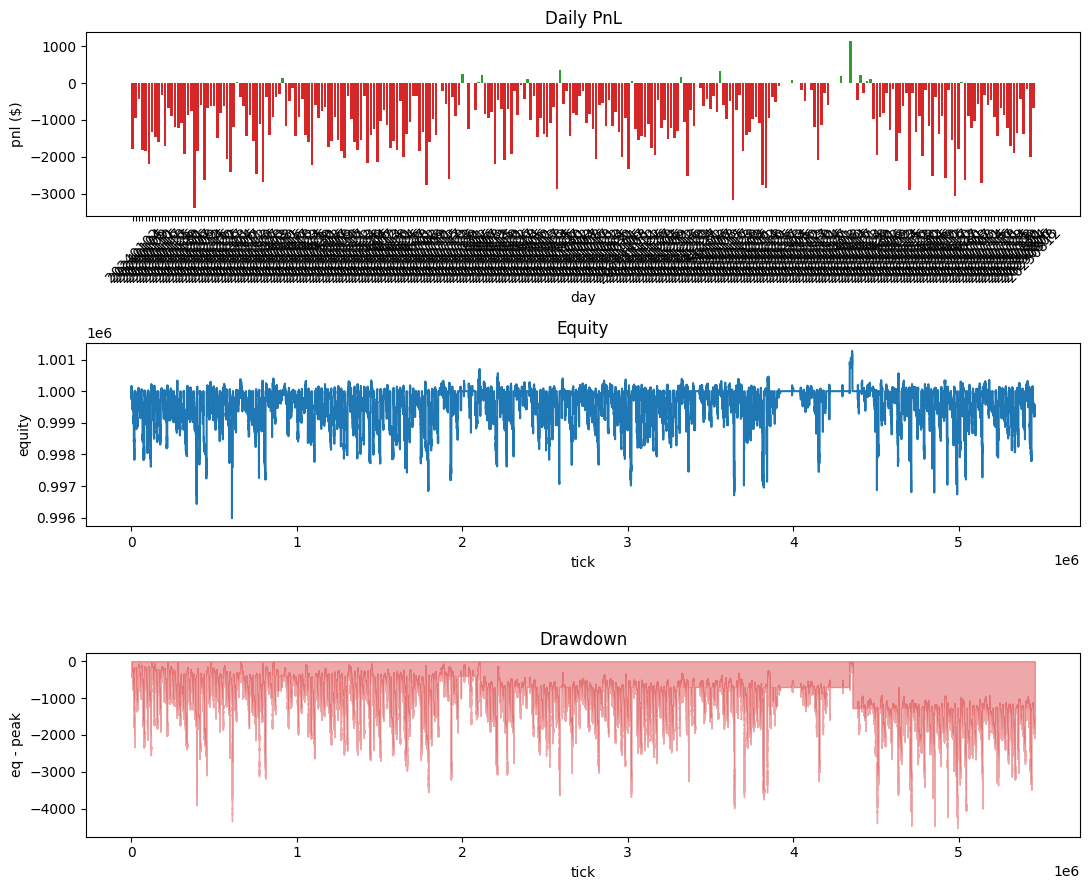

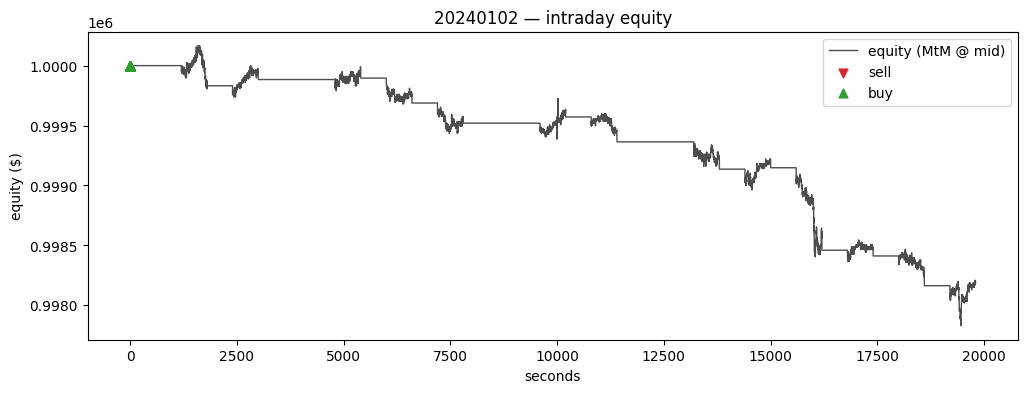

=== trade ledger: 10864 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,exe_cost,state,signal,note,alpha_sec,alpha_spot,alpha_atm,alpha_range_bps,alpha_decision_now
0,20240102,1201,471.0,CE,SELL,20.0,1.23,17.0,0.0,10.0,27.0,SHORT,calm_entry,,1200,471.40,471.0,14.64,1
1,20240102,1201,471.0,PE,SELL,20.0,0.82,17.0,0.0,10.0,27.0,SHORT,calm_entry,,1200,471.40,471.0,14.64,1
2,20240102,1801,471.0,CE,BUY,20.0,1.61,17.0,0.0,20.0,37.0,WAIT,hold_elapsed,square off,1800,472.14,472.0,18.64,0
3,20240102,1801,471.0,PE,BUY,20.0,0.46,17.0,0.0,10.0,27.0,WAIT,hold_elapsed,square off,1800,472.14,472.0,18.64,0
4,20240102,2401,472.0,CE,SELL,20.0,1.00,17.0,0.0,10.0,27.0,SHORT,calm_entry,,2400,472.26,472.0,14.82,1
5,20240102,2401,472.0,PE,SELL,20.0,0.74,17.0,0.0,10.0,27.0,SHORT,calm_entry,,2400,472.26,472.0,14.82,1
6,20240102,3001,472.0,CE,BUY,20.0,0.88,17.0,0.0,10.0,27.0,WAIT,hold_elapsed,square off,3000,472.07,472.0,10.38,0
7,20240102,3001,472.0,PE,BUY,20.0,0.78,17.0,0.0,10.0,27.0,WAIT,hold_elapsed,square off,3000,472.07,472.0,10.38,0
8,20240102,4801,472.0,CE,SELL,20.0,0.57,17.0,0.0,10.0,27.0,SHORT,calm_entry,,4800,471.67,472.0,12.51,1
9,20240102,4801,472.0,PE,SELL,20.0,0.90,17.0,0.0,10.0,27.0,SHORT,calm_entry,,4800,471.67,472.0,12.51,1


fills by signal:


,count,sum
signal,,
calm_entry,5642,161274.0
hold_elapsed,5222,163874.0


=== per-second log 20240102: 19776 rows ===


,timestamp,spot,atm,state,sec,range_bps,decision_now
2000,2002,472.53,473.0,WAIT,2002.0,26.05,False
2001,2003,472.54,473.0,WAIT,2003.0,26.05,False
2002,2004,472.52,473.0,WAIT,2004.0,26.05,False
2003,2005,472.53,473.0,WAIT,2005.0,26.05,False
2004,2006,472.53,473.0,WAIT,2006.0,26.05,False


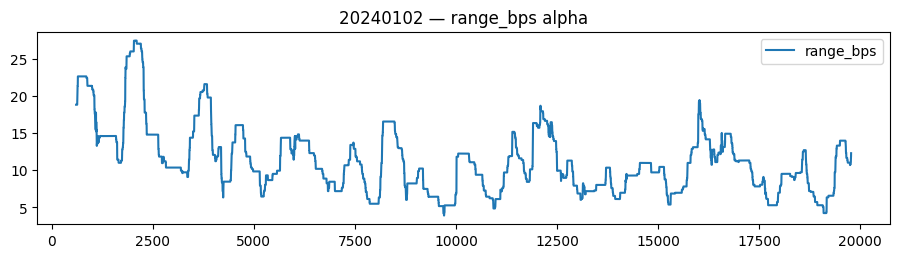

In [ ]:
# import matplotlib.pyplot as plt

# DAY = res.days[0]          # first day in the run (any value in res.days works)

# # ---- 1. per-day summary table ----
# print("=== per-day summary ===")
# display(res.summary)

# # ---- 2. aggregate stats ----
# print("=== aggregate stats ===")
# for k, v in res.stats().items():
#     print(f"  {k:<16}: {v}")

# # ---- 3. plots: daily PnL / stitched equity / drawdown ----
# res.tearsheet()
# plt.show()

# # ---- 4. single-day deep dive: intraday MtM with buy/sell markers ----
# res.plot_day(DAY)
# plt.show()

# # ---- 5. trade ledger (all days) ----
# led = res.Tradelog()
# print(f"=== trade ledger: {len(led)} fills ===")
# display(led.head(10))                                  # alpha_* cols show fire-time values
# print("fills by signal:")
# display(led.groupby("signal")["exe_cost"].agg(["count", "sum"]).round(2))

# # ---- 6. per-second log for one day ----
# sl = res.perseclog(DAY)
# print(f"=== per-second log {DAY}: {len(sl)} rows ===")
# display(sl.iloc[2000:2005])                            # spot, atm, state, every alpha
# sl.plot(y="range_bps", figsize=(11, 2.5), title=f"{DAY} — range_bps alpha")
# plt.show()

In [ ]:
# Reuse the same inspection cell above against `res`:
#   res.summary ; res.stats() ; res.tearsheet() ; res.plot_day(res.days[0]) ; res.Tradelog()
# The `signal` column tells you which regime fired each trade:
led = res.Tradelog()
if not led.empty:
    display(led.groupby("signal")["lots"].agg(["count", "sum"]))
    # per-second regime trace for one day (state + the two headline alphas)
    sl = res.perseclog(res.days[0])
    display(sl[["spot", "vwap", "dev_bps", "range_bps", "state"]].iloc[2000:2008])
